In [5]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# classification related algorithom

from sklearn.linear_model import LogisticRegression,RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier,StackingClassifier

import pickle

import warnings
warnings.filterwarnings("ignore")






In [6]:
df=pd.read_csv("cardiology.csv")
df.head(3)

,age,cholesterol,resting_bp,max_heart_rate,exercise_hours,smoking_status,heart_risk_score,heart_disease
0,75.993457,194.619014,109.133195,80.000000,1.912205,former-smoker,20.261476,Low
1,51.567124,265.209050,143.028468,149.147470,0.000000,non-smoker,0.000000,High
2,NaN,184.491964,163.398311,157.223526,3.546787,current-smoker,14.029866,Low


In [7]:
df.columns

Index(['age', 'cholesterol', 'resting_bp', 'max_heart_rate', 'exercise_hours',
       'smoking_status', 'heart_risk_score', 'heart_disease'],
      dtype='object')

<Axes: >

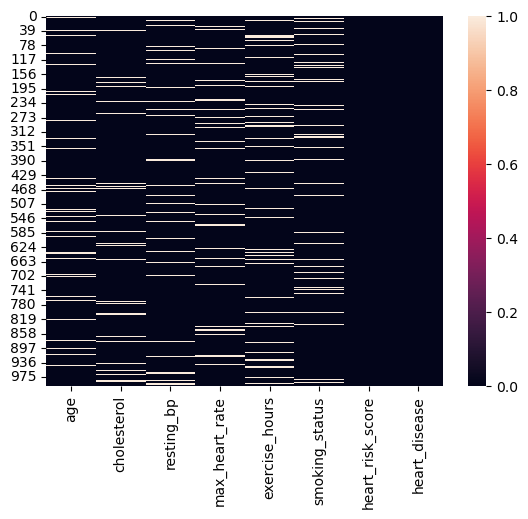

In [8]:
sns.heatmap(df.isnull())

In [14]:
df.shape

(1000, 8)

In [9]:
df.isnull().sum()

age                  99
cholesterol          71
resting_bp           83
max_heart_rate       97
exercise_hours      100
smoking_status       87
heart_risk_score      0
heart_disease         0
dtype: int64

In [12]:
num_feature= df.select_dtypes(include=["int64","float64"])
cat_feature= df.select_dtypes(include=["object"])

In [13]:
num_feature

,age,cholesterol,resting_bp,max_heart_rate,exercise_hours,heart_risk_score
0,75.993457,194.619014,109.133195,80.000000,1.912205,20.261476
1,51.567124,265.209050,143.028468,149.147470,0.000000,0.000000
2,NaN,184.491964,163.398311,157.223526,3.546787,14.029866
3,30.000000,238.174257,153.975022,144.707008,2.500785,0.000000
4,54.900584,265.782958,NaN,104.007520,5.111838,0.000000
...,...,...,...,...,...,...
995,36.519918,202.660833,NaN,210.000000,0.149936,20.658325
996,63.059700,NaN,147.599770,176.867870,2.955069,0.000000
997,52.859497,NaN,147.112942,123.369864,3.867306,10.254688
998,46.376458,181.421192,121.378828,176.834075,2.261994,29.221297


In [15]:
cat_feature

,smoking_status,heart_disease
0,former-smoker,Low
1,non-smoker,High
2,current-smoker,Low
3,non-smoker,High
4,former-smoker,High
...,...,...
995,former-smoker,Low
996,former-smoker,High
997,non-smoker,Low
998,former-smoker,Low


In [20]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,901.0,54.860286,11.779294,30.0,46.798640,54.845804,62.915255,85.000000
cholesterol,929.0,221.078045,35.618324,120.0,197.538065,222.384103,246.823329,308.610044
resting_bp,917.0,135.309545,19.880431,90.0,121.554711,134.707115,148.432160,200.000000
max_heart_rate,903.0,150.220352,25.151393,80.0,133.090739,150.681905,167.979083,210.000000
exercise_hours,900.0,2.551835,1.452830,0.0,1.551640,2.543360,3.549001,7.520436
heart_risk_score,1000.0,10.108550,11.837858,0.0,0.000000,6.289195,17.744550,68.210675


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               901 non-null    float64
 1   cholesterol       929 non-null    float64
 2   resting_bp        917 non-null    float64
 3   max_heart_rate    903 non-null    float64
 4   exercise_hours    900 non-null    float64
 5   smoking_status    913 non-null    object 
 6   heart_risk_score  1000 non-null   float64
 7   heart_disease     1000 non-null   object 
dtypes: float64(6), object(2)
memory usage: 62.6+ KB


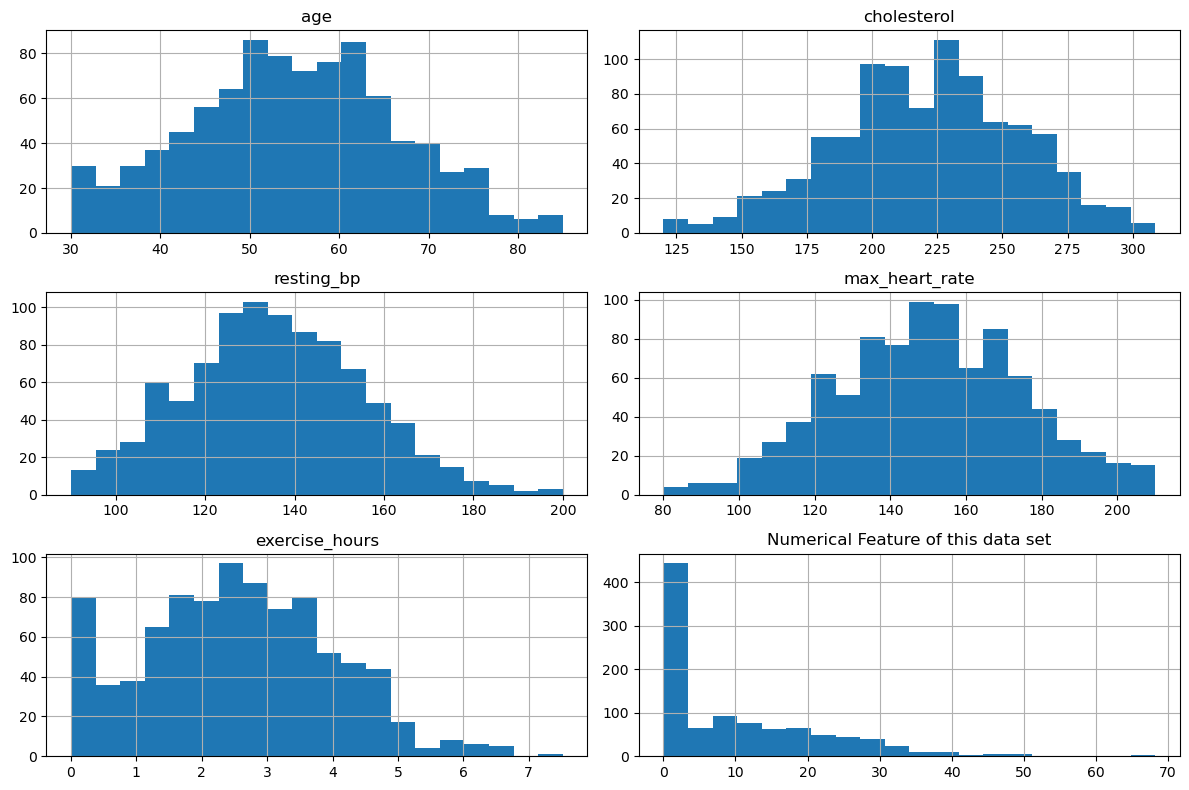

In [28]:
df[num_feature.columns].hist(bins=20,figsize=(12,8))
plt.tight_layout()
plt.title("Numerical Feature of this data set")
plt.show()

In [26]:
df.isnull().sum()

age                  99
cholesterol          71
resting_bp           83
max_heart_rate       97
exercise_hours      100
smoking_status       87
heart_risk_score      0
heart_disease         0
dtype: int64

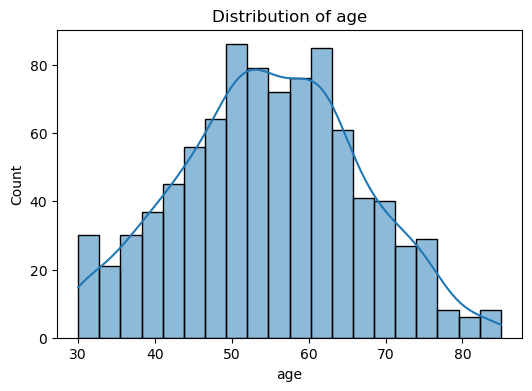

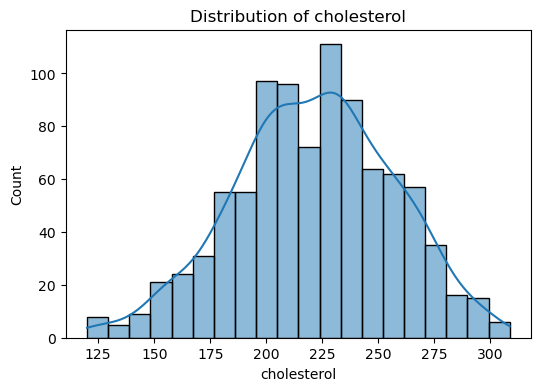

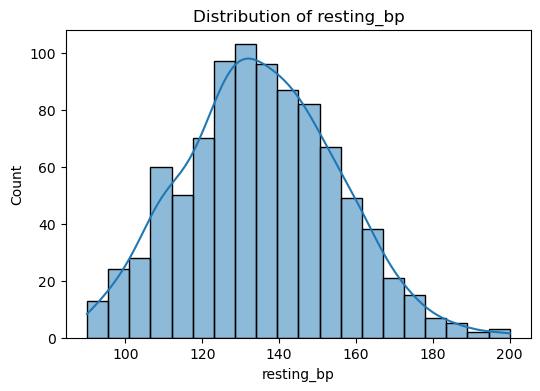

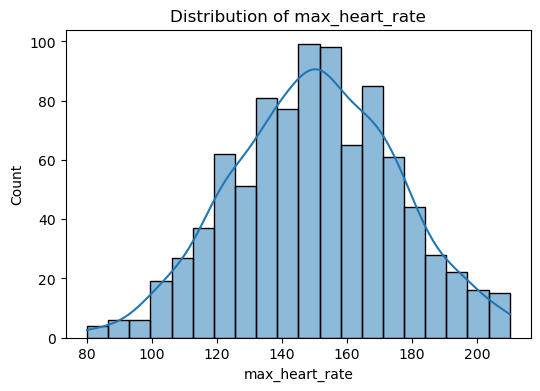

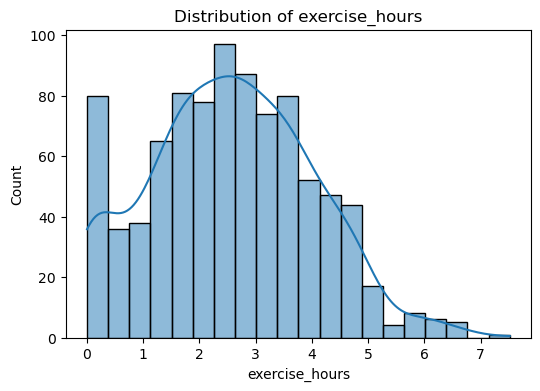

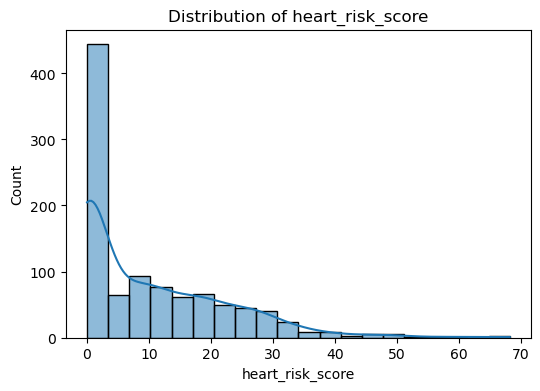

In [30]:
for col in num_feature.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

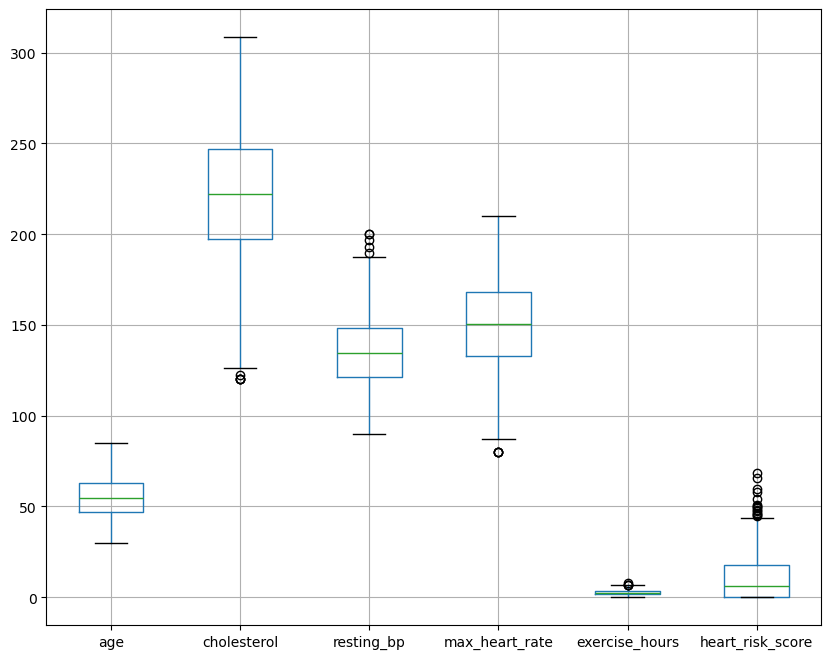

In [ ]:
plt.figure(figsize=(10,8))
df[num_feature.columns].boxplot()   
plt.show()

In [33]:
df.columns

Index(['age', 'cholesterol', 'resting_bp', 'max_heart_rate', 'exercise_hours',
       'smoking_status', 'heart_risk_score', 'heart_disease'],
      dtype='object')

#Handle outliar

In [31]:
col="resting_bp"
q1=df[col].quantile(0.25)
q3=df[col].quantile(0.75)
IQR=q3-q1

lower=q1-1.5*IQR
upper=q3+1.5*IQR

outliar=df[(df[col]<lower)|(df[col]>upper)]
print(f"Number of detected outliar is {col}",len(outliar))



Number of detected outliar is resting_bp 5


In [32]:
# handle this outliar

df = df.copy()
df[col] = df[col].clip(lower,upper)

In [34]:
col="heart_risk_score"
q1=df[col].quantile(0.25)
q3=df[col].quantile(0.75)
IQR=q3-q1

lower=q1-1.5*IQR
upper=q3+1.5*IQR

outliar=df[(df[col]<lower)|(df[col]>upper)]
print(f"Number of detected outliar is {col}",len(outliar))


Number of detected outliar is heart_risk_score 15


In [35]:
df = df.copy()
df[col] = df[col].clip(lower,upper)

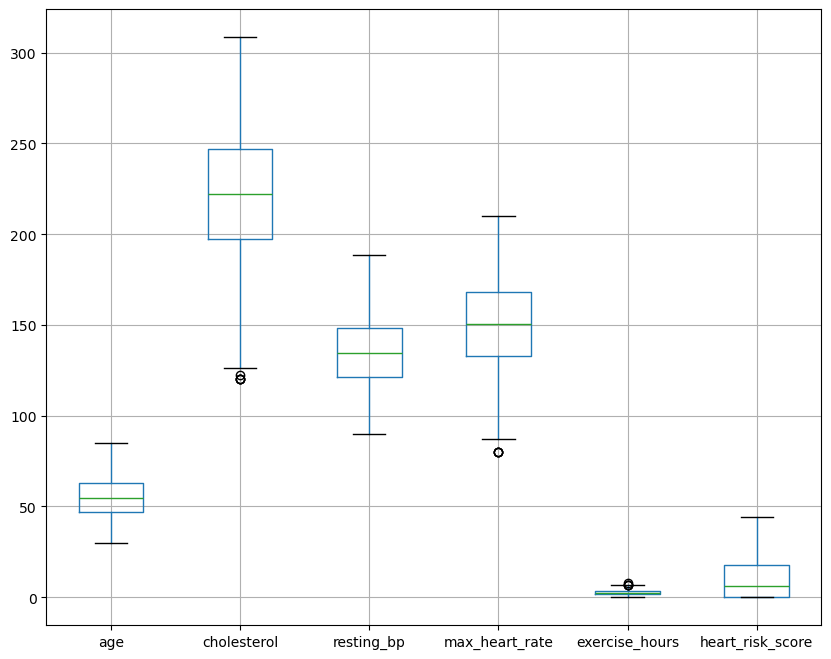

In [36]:
# see this outliar
plt.figure(figsize=(10,8))
df[num_feature.columns].boxplot()   
plt.show()

In [37]:
df.columns

Index(['age', 'cholesterol', 'resting_bp', 'max_heart_rate', 'exercise_hours',
       'smoking_status', 'heart_risk_score', 'heart_disease'],
      dtype='object')

In [40]:
# separate  x and y

x= df.drop('heart_disease',axis=1)
y=df['heart_disease']

In [41]:
y

0       Low
1      High
2       Low
3      High
4      High
       ... 
995     Low
996    High
997     Low
998     Low
999    High
Name: heart_disease, Length: 1000, dtype: object

In [42]:
le=LabelEncoder()
y_encoded=le.fit_transform(y)

In [45]:
y_encoded

array([1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0,

Redefine catagorical feature and numerical feature 

In [46]:
numerical_feature= x.select_dtypes(include=['int64','float64'])
categorical_feature= x.select_dtypes(include=['object'])

In [47]:
numerical_feature

,age,cholesterol,resting_bp,max_heart_rate,exercise_hours,heart_risk_score
0,75.993457,194.619014,109.133195,80.000000,1.912205,20.261476
1,51.567124,265.209050,143.028468,149.147470,0.000000,0.000000
2,NaN,184.491964,163.398311,157.223526,3.546787,14.029866
3,30.000000,238.174257,153.975022,144.707008,2.500785,0.000000
4,54.900584,265.782958,NaN,104.007520,5.111838,0.000000
...,...,...,...,...,...,...
995,36.519918,202.660833,NaN,210.000000,0.149936,20.658325
996,63.059700,NaN,147.599770,176.867870,2.955069,0.000000
997,52.859497,NaN,147.112942,123.369864,3.867306,10.254688
998,46.376458,181.421192,121.378828,176.834075,2.261994,29.221297


In [48]:
categorical_feature

,smoking_status
0,former-smoker
1,non-smoker
2,current-smoker
3,non-smoker
4,former-smoker
...,...
995,former-smoker
996,former-smoker
997,non-smoker
998,former-smoker


In [49]:
corr_target = df.select_dtypes(include=np.number).corr()['HeartDisease'].sort_values(ascending=False)

KeyError: 'HeartDisease'